In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline
import sys
import os
sys.path.append('../../results_analysis')
from utils import generate_anndata_from_ark_analysis
base_dir = "../../../"

In [2]:
reload = True
if reload:
    adata = sc.read_h5ad('data/sc_protein.h5ad')
else:
    adata = generate_anndata_from_ark_analysis(cell_table_path=base_dir+'segmentation/cell_table_Denoised/cell_table_size_normalized.csv',biosamples_path=base_dir+'IMC_data/ExtraDocs/processed_response.csv')
    channels = ['CD38', 'CD14', 'Tbet', 'CD16', 'CD163',
       'Pan-keratin', 'CD11b', 'CD107a', 'CD45', 'CD44', 'CD366',
       'FOXP3', 'CD4', 'E-Cadherin', 'CD68', 'HLA-DR-DQ-DP', 'CD20',
       'CD8a', 'Beta-Catenin', 'B7-H4', 'Granzyme-B',
       'CD3', 'CD27', 'CD45RO',
       'Alpha-SMA', 'Vimentin', 'CD31' ]
    adata.var['marker_channel'] = adata.var.index.isin(channels)
    adata.full = adata
    #filter for phenotype marker only
    adata=adata[:,adata.var.marker_channel]
    #Normalise each channel independently by quantile
    adata.X = adata.X/np.quantile(adata.X,0.95,axis = 0)
    adata.X[adata.X>1]=1
    
    sc.tl.pca(adata)
    sc.external.tl.phenograph(adata, clustering_algo="louvain", k=30)
    #consider whether to overwrite
    data_folder = 'data/'
    if not os.path.exists(data_folder):
        os.makedirs(data_folder)
    adata.write('data/sc_protein.h5ad')

If one fancies umap


In [3]:
sc.pp.neighbors(adata, n_neighbors=10,method = 'rapids')
sc.tl.umap(adata,method = 'rapids')

/home/giuseppe/anaconda3/envs/rapids-23.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2023-11-23 17:02:25.952466: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-11-23 17:02:25.987139: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-11-23 17:02:25.987174: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-1

In [20]:
adata.obs['pheno_louvain']

0          58
2          58
3          58
4          58
5          43
           ..
3964191     7
3964192     7
3964193     1
3964194     4
3964195    12
Name: pheno_louvain, Length: 3013318, dtype: category
Categories (79, int64): [0, 1, 2, 3, ..., 75, 76, 77, 78]

In [4]:
cluster_mean_expr = pd.DataFrame()
for cluster,cell_ids in adata.obs.groupby('pheno_louvain').groups.items():
    cluster_mean_expr[cluster] =adata[cell_ids].X.mean(axis = 0)
cluster_mean_expr.index = adata.var.index

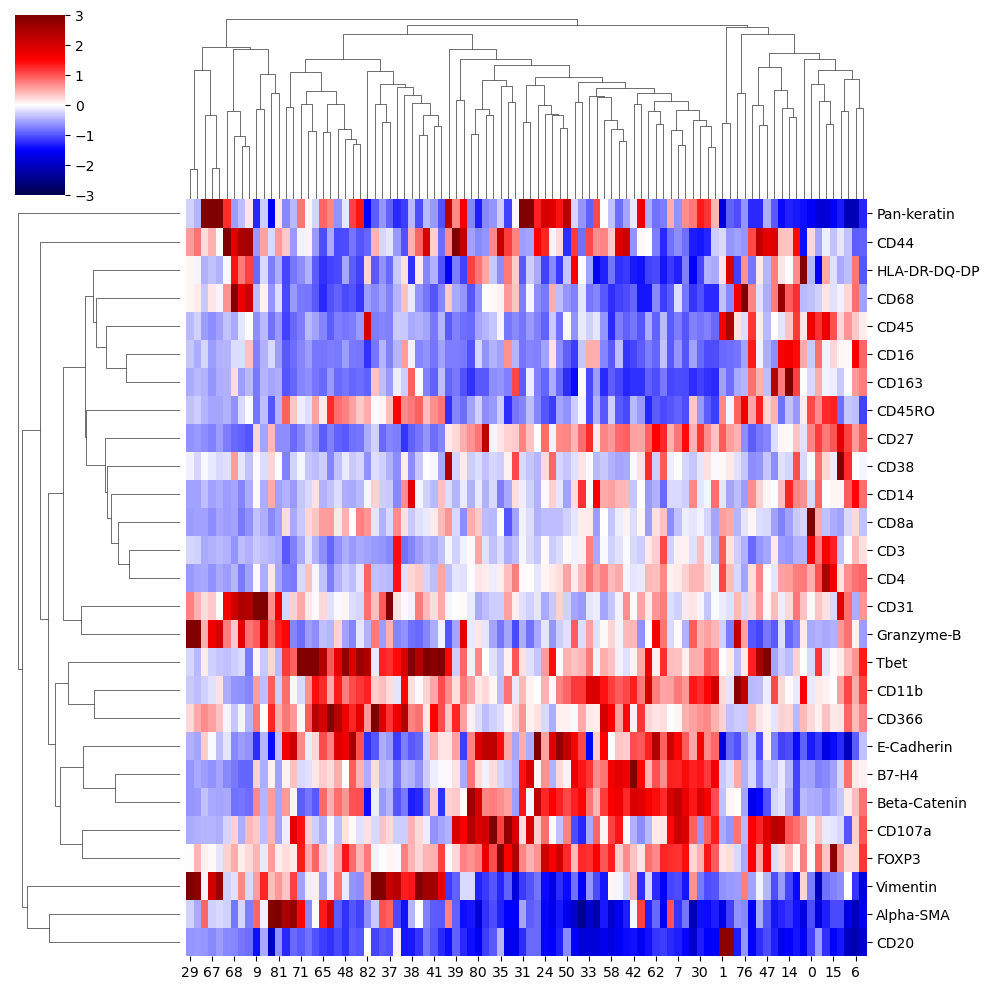

In [5]:
sns.clustermap(cluster_mean_expr,z_score=1,cmap = 'seismic',vmin = -3,vmax = 3)
#plt.savefig('phenograph_clustermap.png')

<Axes: >

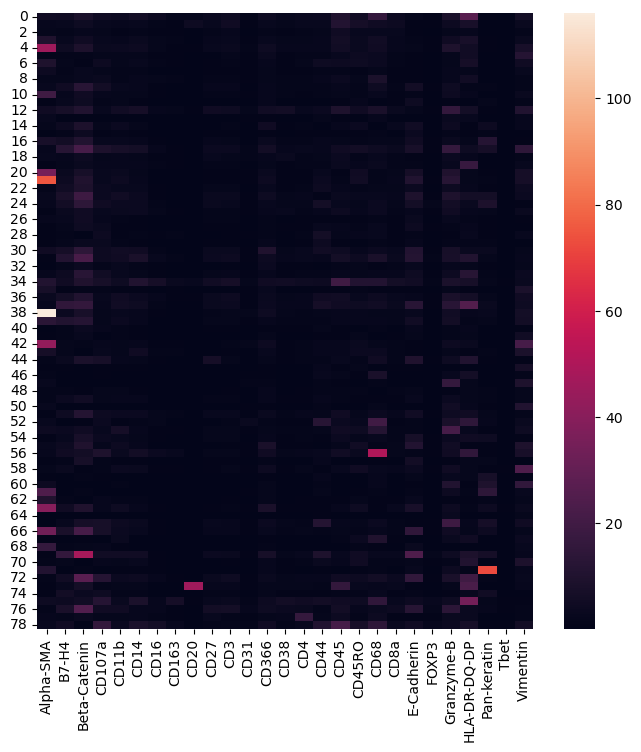

In [41]:
plt.figure(figsize =( 8,8))
sns.heatmap(cluster_mean_expr.T)


In [107]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
#from cuml.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
#from sklearn.model_selection import RandomizedSearchCV
from cuml.model_selection import GridSearchCV
from cuml.linear_model import LogisticRegression

In [106]:
X = adata.X
y = np.array(list(adata.obs['pheno_louvain'].values),dtype = int)
X_train, X_val, y_train, y_val = train_test_split(X,y , test_size=0.2)


In [38]:
lr = LogisticRegression(C=0.5 ).fit(X_train, y_train)


In [108]:
dtr = DecisionTreeClassifier(max_depth=3)
dtr.fit(X_train, y_train)
# Making predictions on the validation set
y_pred = dtr.predict(X_val)

# Calculating accuracy on each validation set
accuracy = accuracy_score(y_val, y_pred)
print(accuracy_score(y_train,dtr.predict(X_train)),accuracy)

0.17341061803145535 0.17421481953459972


In [39]:
# Making predictions on the validation set
y_pred = lr.predict(X_val)

# Calculating accuracy on each validation set
accuracy = accuracy_score(y_val, y_pred)
print(accuracy_score(y_train,lr.predict(X_train)),accuracy)

0.8419777371617827 0.8407321492572976


(92, 27)

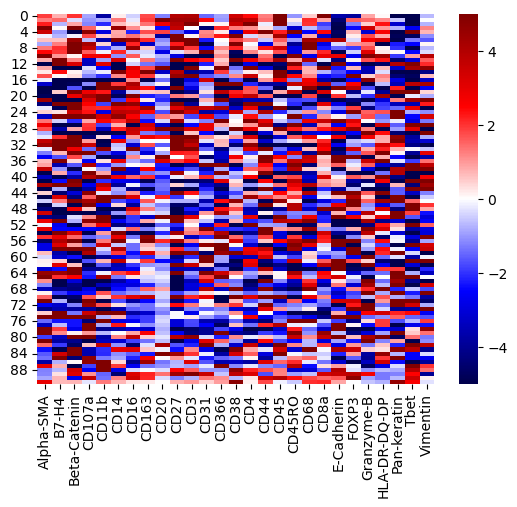

In [34]:
sns.heatmap(pd.DataFrame(lr.coef_,columns = adata.var.index),cmap = 'seismic',vmin = -5,vmax = 5)
lr.coef_.shape

In [96]:
annotation_table = pd.read_csv('~/devices/Delta_Tissue/IMC/IMC_data/IMCCelltypeResults/cell_type_matrix.csv',index_col=0)

annotation_table = annotation_table.drop(['Proliferative cells?', 'p53+ cells?', 'Neutrophil&monocyte',
       'Other cells'],axis = 1)
annotation_table = annotation_table[~annotation_table.isna().all(axis = 1)]
annotation_table.fillna(0,inplace=True)

In [99]:
score = pd.DataFrame(lr.coef_,columns = adata.var.index).loc[:,annotation_table.index]@annotation_table

<Axes: >

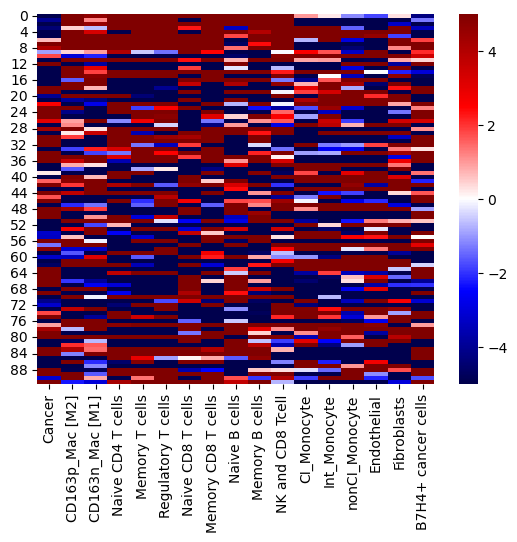

In [102]:
sns.heatmap(score,cmap = 'seismic',vmin = -5,vmax = 5)

5.533728896062494

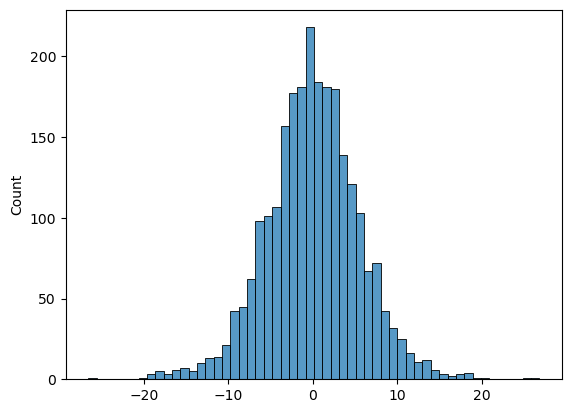

In [103]:
sns.histplot(lr.coef_.reshape(-1))
lr.coef_.reshape(-1).std()

In [18]:
X = adata.X
y = np.array(list(adata.obs['pheno_louvain'].values),dtype = int)
X_train, X_val, y_train, y_val = train_test_split(X,y , test_size=0.2)

rf_classifier = RandomForestClassifier(n_estimators=20)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20)

In [13]:
# Making predictions on the validation set
y_pred = dtr_classifier.predict(X_val)

# Calculating accuracy on each validation set
accuracy = accuracy_score(y_val, y_pred)
print(accuracy_score(y_train,rf_classifier.predict(X_train)),accuracy)

0.8075679877742721 0.7820277965831707


Text(0.5, 1.0, 'Random Forest Feature Importances')

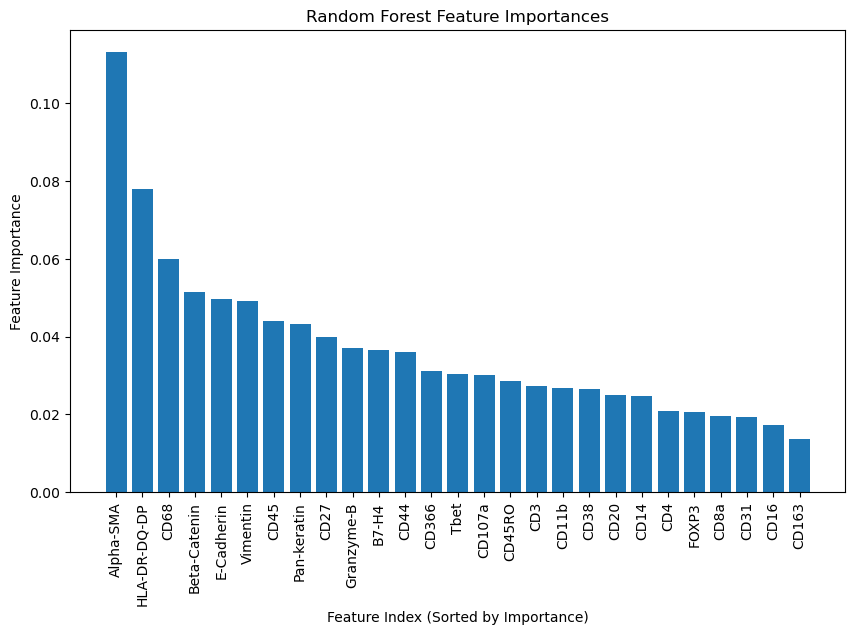

In [25]:

# Extracting feature importances
feature_importances = rf_classifier.feature_importances_

# Sorting feature importances in descending order
sorted_indices = feature_importances.argsort()[::-1]

# Plotting feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), feature_importances[sorted_indices])
plt.xticks(range(X.shape[1]), adata.var.index[sorted_indices],rotation = 90)
plt.xlabel('Feature Index (Sorted by Importance)')
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importances')

In [20]:
adata.var.index

Index(['Alpha-SMA', 'B7-H4', 'Beta-Catenin', 'CD107a', 'CD11b', 'CD14', 'CD16',
       'CD163', 'CD20', 'CD27', 'CD3', 'CD31', 'CD366', 'CD38', 'CD4', 'CD44',
       'CD45', 'CD45RO', 'CD68', 'CD8a', 'E-Cadherin', 'FOXP3', 'Granzyme-B',
       'HLA-DR-DQ-DP', 'Pan-keratin', 'Tbet', 'Vimentin'],
      dtype='object')

In [21]:
feature_importances

array([0.11321884, 0.03652939, 0.05138651, 0.03019046, 0.0267333 ,
       0.02478168, 0.01729562, 0.01365442, 0.02494772, 0.03994624,
       0.02728697, 0.01922227, 0.03106248, 0.02657191, 0.02073938,
       0.03602503, 0.04403589, 0.02847471, 0.05999943, 0.01956367,
       0.04971919, 0.0206965 , 0.03702628, 0.07809192, 0.04316848,
       0.03043297, 0.04919876])